# 🌸 The Iris Dataset: A Deep Visual Exploration
### From Raw Data to Stunning Insights — A Complete Data Science Showcase

---

## 🎯 Problem Statement & Goal

> **Goal:** Explore and visualize the classic Iris dataset using advanced statistical and visual techniques to uncover hidden patterns, distributions, and separability between the three species of Iris flowers.

The **Iris dataset** (introduced by R.A. Fisher in 1936) contains measurements of 150 Iris flowers across 3 species:  
- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

Each flower has **4 numeric features** measured in centimeters:
| Feature | Description |
|---------|-------------|
| `sepal_length` | Length of the sepal |
| `sepal_width` | Width of the sepal |
| `petal_length` | Length of the petal |
| `petal_width` | Width of the petal |

### 📌 What We Will Do:
1. Load and inspect the dataset (shape, types, statistics)
2. Generate **10+ beautiful visualizations** including scatter plots, histograms, box plots, violin plots, heatmaps, PCA, LDA, and more
3. Extract meaningful biological and statistical insights

---

## Step 1 — Import Libraries & Configure Plotting Style

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# IMPORTS — All required libraries for data loading, analysis, and visualization
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# GLOBAL STYLE CONFIGURATION — Consistent beautiful look across all plots
# ─────────────────────────────────────────────────────────────────────────────

# Custom color palette — elegant and distinct per species
PALETTE = {
    'setosa':     '#E84855',   
    'versicolor': '#3A86FF',   
    'virginica':  '#06D6A0'    
}
COLORS = list(PALETTE.values())

# Background & font styling
BG_COLOR    = '#0F0F1A'   
GRID_COLOR  = '#1E1E35'
TEXT_COLOR  = '#E8E8F0'
ACCENT      = '#FFD166'   

plt.rcParams.update({
    'figure.facecolor':  BG_COLOR,
    'axes.facecolor':    BG_COLOR,
    'axes.edgecolor':    GRID_COLOR,
    'axes.labelcolor':   TEXT_COLOR,
    'axes.titlecolor':   TEXT_COLOR,
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'axes.grid':         True,
    'grid.color':        GRID_COLOR,
    'grid.linewidth':    0.6,
    'xtick.color':       TEXT_COLOR,
    'ytick.color':       TEXT_COLOR,
    'text.color':        TEXT_COLOR,
    'legend.facecolor':  '#1A1A2E',
    'legend.edgecolor':  GRID_COLOR,
    'legend.fontsize':   10,
    'font.family':       'DejaVu Sans',
    'figure.dpi':        130,
})

print('✅ All libraries imported successfully!')
print('✅ Custom plot style configured — dark theme with species-distinct palette')

## Step 2 — Load the Iris Dataset

We load the Iris dataset directly from **scikit-learn**, which bundles it locally — *no download required*. We then convert it to a tidy pandas DataFrame with proper column names and a human-readable species column.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATASET — Using sklearn's bundled Iris
# ─────────────────────────────────────────────────────────────────────────────

iris_raw = load_iris()

# Build clean DataFrame with descriptive column names
iris = pd.DataFrame(
    iris_raw.data,
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

# Map numeric targets (0,1,2) → actual species names
iris['species'] = pd.Categorical.from_codes(
    iris_raw.target,
    iris_raw.target_names
)

# Feature columns (numeric only) — used repeatedly throughout
FEATURES = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

print('✅ Dataset loaded successfully!')
print(f'   Source  : sklearn.datasets.load_iris (built-in, no download needed)')
print(f'   Rows    : {iris.shape[0]}')
print(f'   Columns : {iris.shape[1]}')
print(f'   Species : {list(iris_raw.target_names)}')

✅ Dataset loaded successfully!
   Source  : sklearn.datasets.load_iris (built-in, no download needed)
   Rows    : 150
   Columns : 5
   Species : ['setosa', 'versicolor', 'virginica']


## Step 3 — Initial Inspection: Shape, Head, Info, Describe

Before any visualization, we always inspect the raw data to understand its **structure**, **types**, and **statistical profile**.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SHAPE & COLUMN NAMES
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 55)
print('  DATASET OVERVIEW')
print('=' * 55)
print(f'  Shape          : {iris.shape}  →  (rows, columns)')
print(f'  Column names   : {iris.columns.tolist()}')
print(f'  Missing values : {iris.isnull().sum().sum()}  (perfect — no NaNs!)')
print(f'  Samples/species: {dict(iris.species.value_counts())}')
print('=' * 55)
print()
print('📋 First 5 rows:')
iris.head()

  DATASET OVERVIEW
  Shape          : (150, 5)  →  (rows, columns)
  Column names   : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
  Missing values : 0  (perfect — no NaNs!)
  Samples/species: {'setosa': 50, 'versicolor': 50, 'virginica': 50}

📋 First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# .info() — Data types, non-null counts, memory usage
# ─────────────────────────────────────────────────────────────────────────────

print('📋 Dataset Info (.info()):')  
print('-' * 40)
iris.info()

📋 Dataset Info (.info()):
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sepal_length  150 non-null    float64 
 1   sepal_width   150 non-null    float64 
 2   petal_length  150 non-null    float64 
 3   petal_width   150 non-null    float64 
 4   species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# .describe() — Statistical summary: mean, std, min, quartiles, max
# ─────────────────────────────────────────────────────────────────────────────

print('📊 Statistical Summary (.describe()):')
iris.describe().round(2)

📊 Statistical Summary (.describe()):


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# BONUS: Per-species statistics — shows how different each class truly is
# ─────────────────────────────────────────────────────────────────────────────

print('📊 Mean feature values per species:')
iris.groupby('species')[FEATURES].mean().round(2)

📊 Mean feature values per species:


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


## Step 4 — Visualization Suite

We now generate a comprehensive set of **10 publication-grade visualizations**, each revealing a different layer of insight.

| # | Plot Type | What It Reveals |
|---|-----------|----------------|
| 4.1 | Scatter Matrix (Pair Plot) | Pairwise feature relationships & species clusters |
| 4.2 | Correlation Heatmap | Which features are most correlated |
| 4.3 | Histograms with KDE | Feature value distributions per species |
| 4.4 | Box Plots | Spread, median, and outliers per species |
| 4.5 | Violin Plots | Distribution shape + statistical summary combined |
| 4.6 | Swarm Plot | Every single data point, no overlap |
| 4.7 | 2D PCA Projection | Dimensional reduction — do species cluster? |
| 4.8 | LDA Projection | Maximally-separating linear projection |
| 4.9 | Radar / Spider Chart | Feature profile per species |
| 4.10 | Andrews Curves | Multivariate pattern visualization |

---

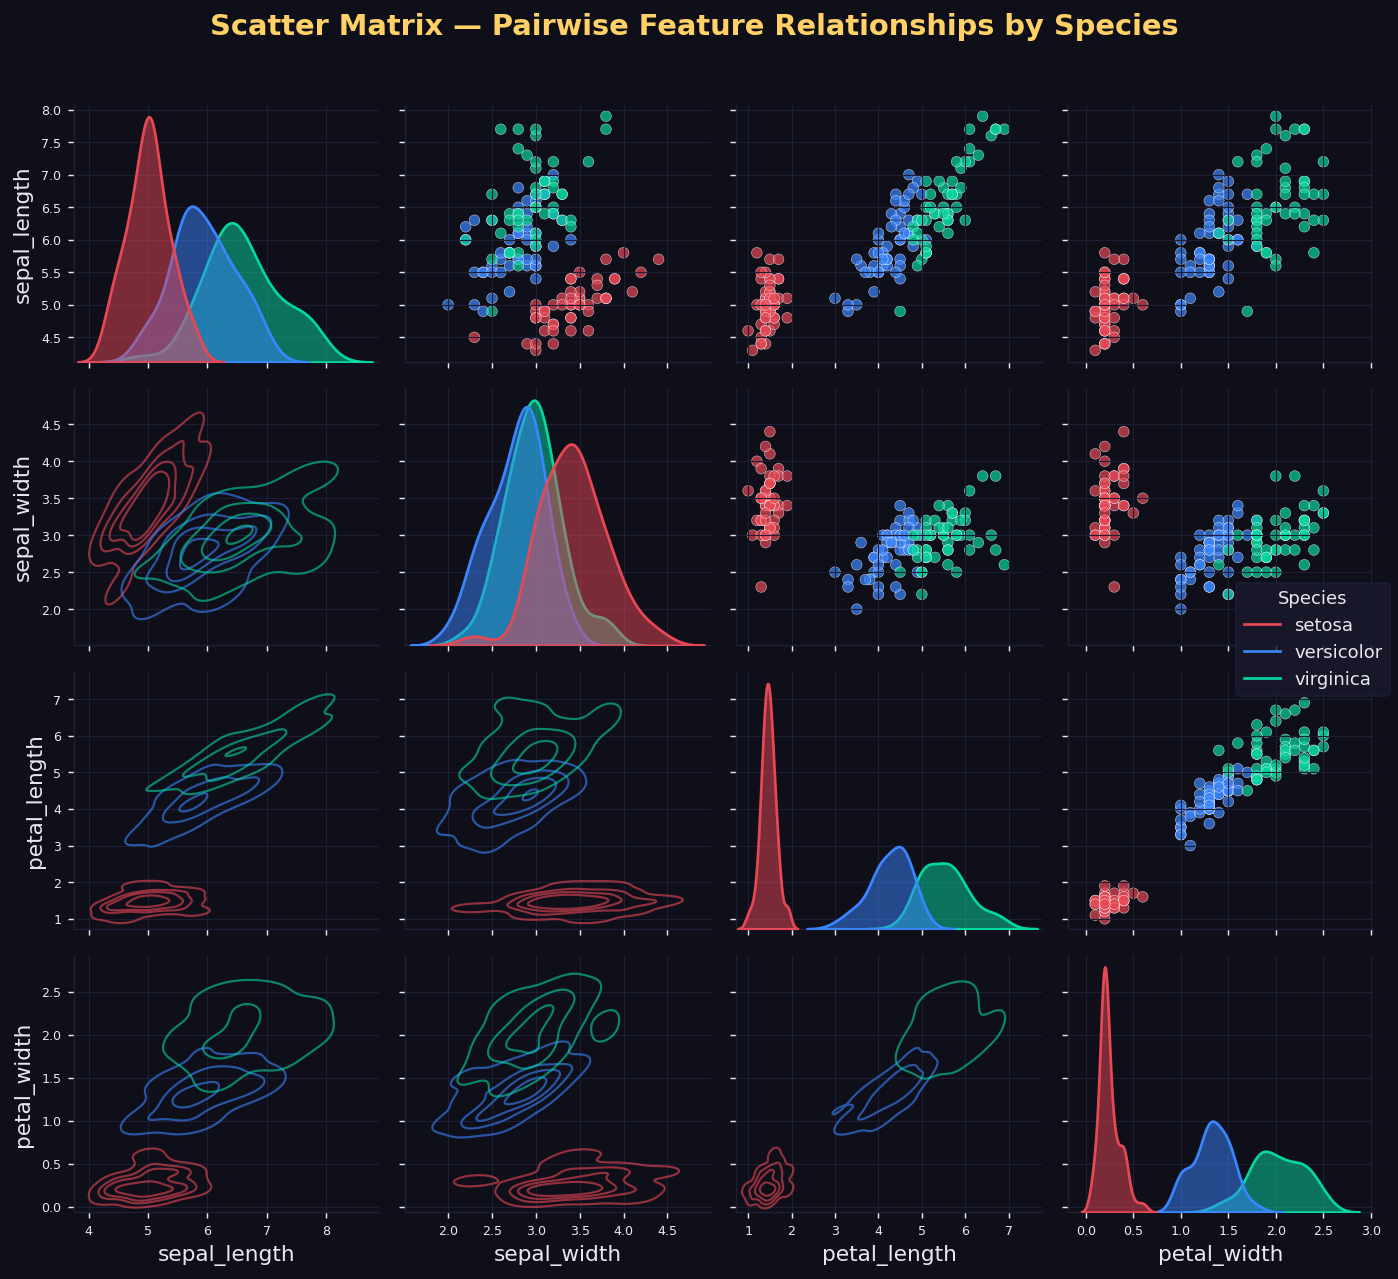

📌 Insight: Petal length & petal width are the best separators.
   Setosa is clearly isolated; versicolor and virginica overlap slightly.


In [7]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 4.1 — SCATTER MATRIX (Pair Plot)
# Shows every pair of features plotted against each other.
# Diagonal = KDE distribution; Off-diagonal = scatter plot.
# Great for spotting which feature pairs best separate the species.
# ═════════════════════════════════════════════════════════════════════════════

g = sns.PairGrid(
    iris,
    hue='species',
    palette=PALETTE,
    diag_sharey=False,
    height=2.4
)

# Upper triangle: scatter with transparency
g.map_upper(sns.scatterplot, alpha=0.7, s=35, edgecolor='white', linewidth=0.3)

# Diagonal: smooth KDE
g.map_diag(sns.kdeplot, fill=True, alpha=0.5, linewidth=1.5)

# Lower triangle: KDE 2D contours
g.map_lower(sns.kdeplot, levels=5, alpha=0.6, linewidths=1.2)

g.add_legend(title='Species', frameon=True)

# Style the grid
g.figure.set_facecolor(BG_COLOR)
for ax in g.axes.flatten():
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=7)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)

g.figure.suptitle(
    'Scatter Matrix — Pairwise Feature Relationships by Species',
    y=1.02, fontsize=16, color=ACCENT, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('📌 Insight: Petal length & petal width are the best separators.')
print('   Setosa is clearly isolated; versicolor and virginica overlap slightly.')

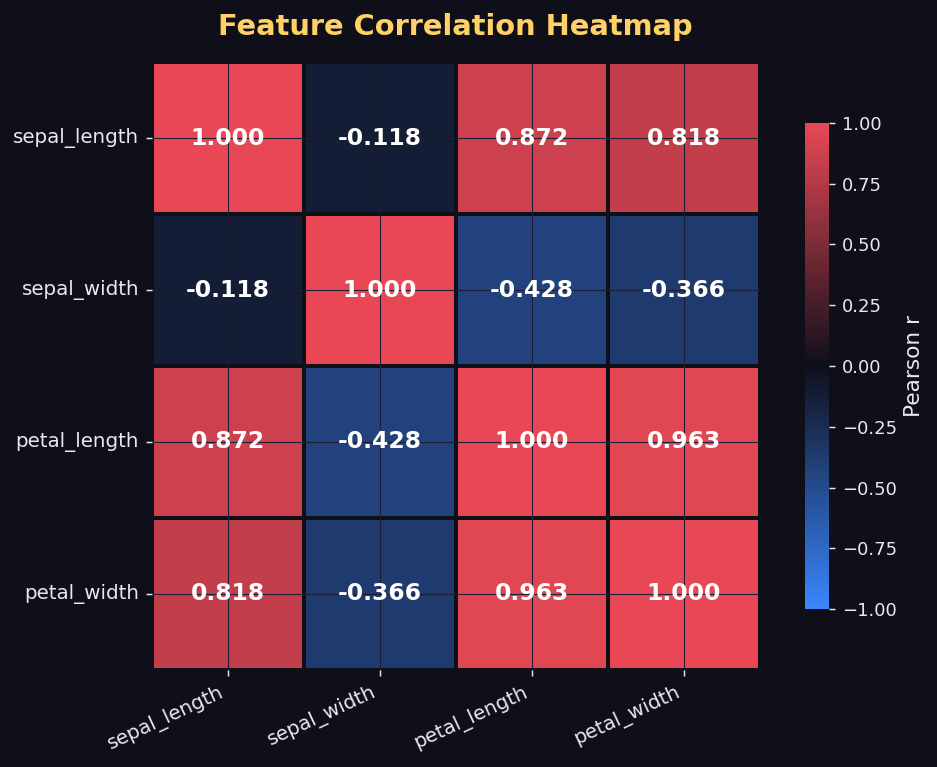

📌 Insight: Petal length ↔ petal width has the strongest correlation (r ≈ 0.96).
   Sepal width is nearly uncorrelated with petal dimensions.


In [8]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 4.2 — CORRELATION HEATMAP
# Shows the Pearson correlation coefficient between every pair of features.
# Values close to ±1 = strong linear relationship.
# ═════════════════════════════════════════════════════════════════════════════

corr_matrix = iris[FEATURES].corr()

# Custom diverging colormap (cool-to-warm)
cmap = LinearSegmentedColormap.from_list(
    'custom_div',
    ['#3A86FF', '#0F0F1A', '#E84855'],
    N=256
)

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle

sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.3f',
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    linewidths=2,
    linecolor=BG_COLOR,
    annot_kws={'size': 13, 'weight': 'bold'},
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)

ax.set_title('Feature Correlation Heatmap', fontsize=16, color=ACCENT,
             fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

print('📌 Insight: Petal length ↔ petal width has the strongest correlation (r ≈ 0.96).')
print('   Sepal width is nearly uncorrelated with petal dimensions.')

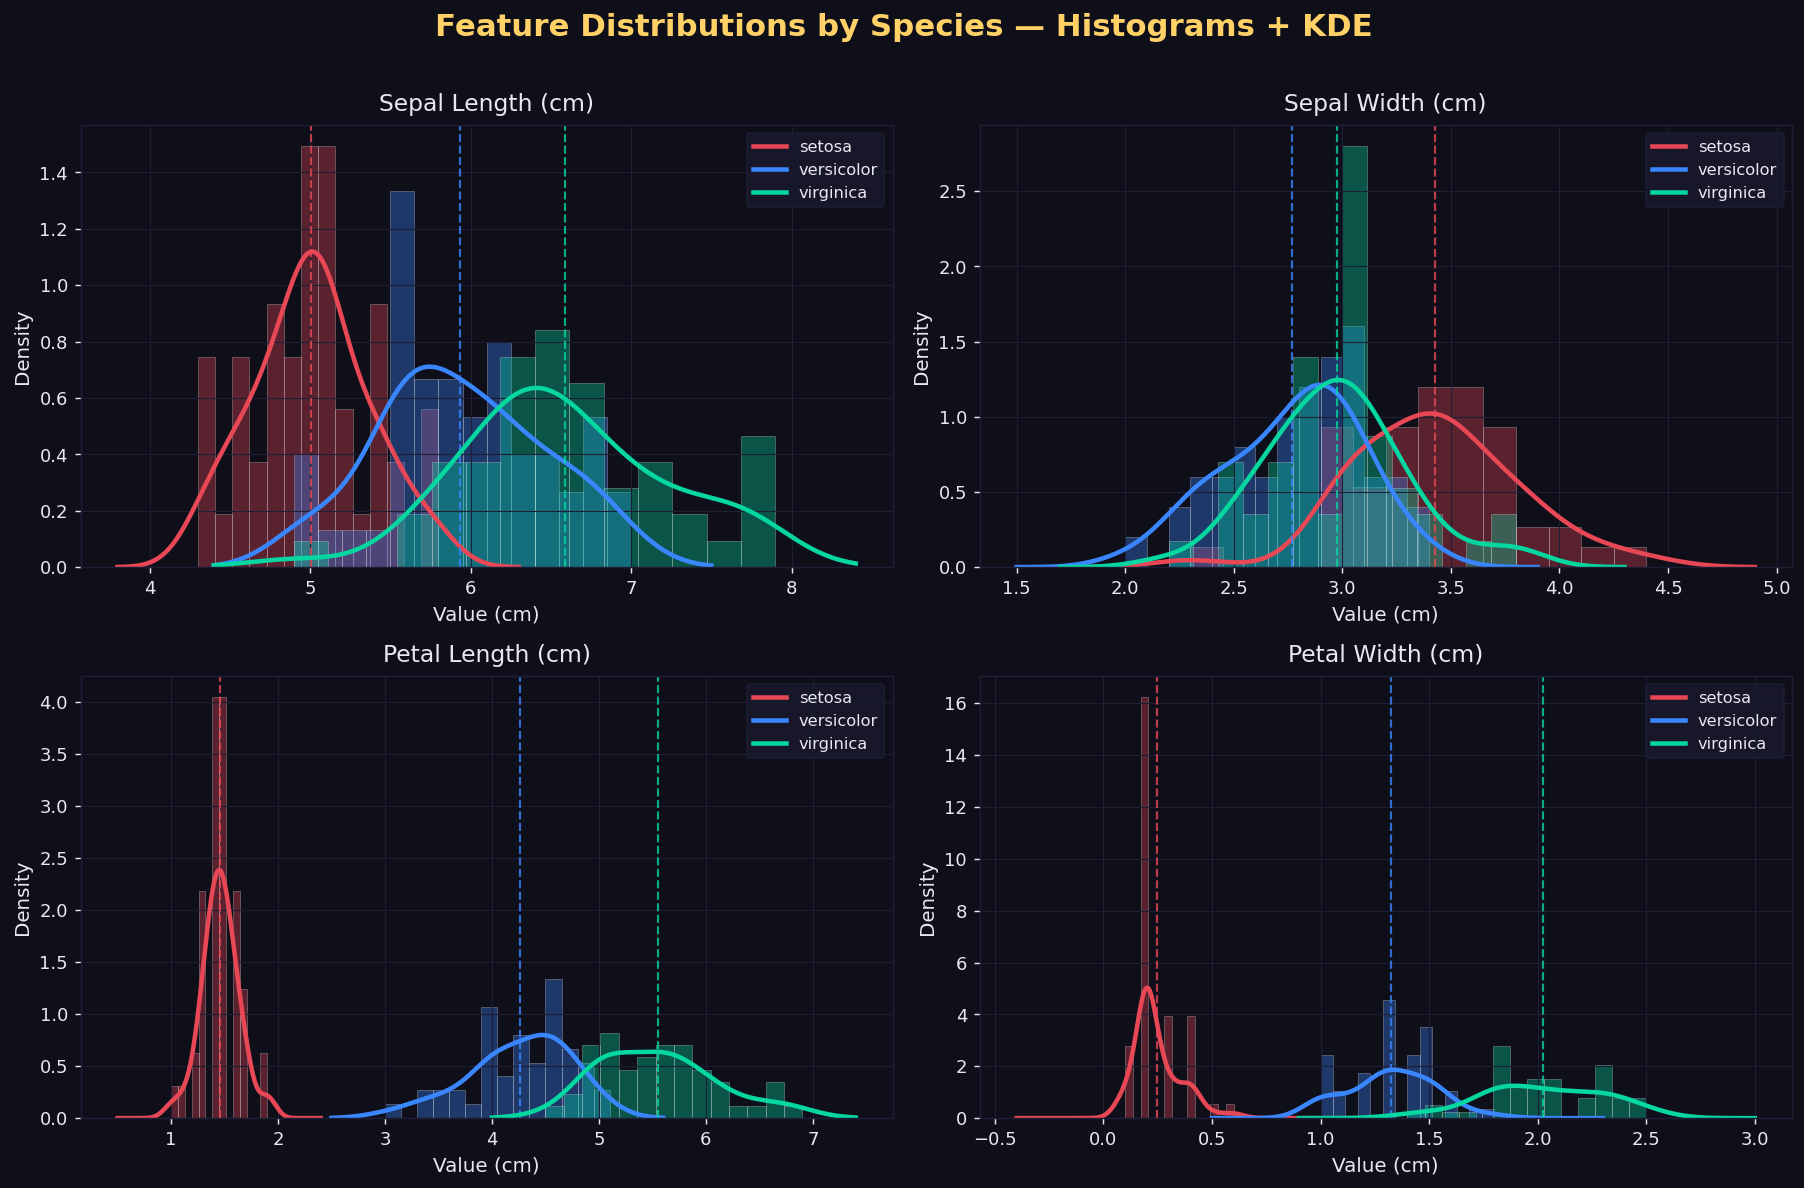

📌 Insight: Petal features show bimodal separation — setosa peaks are far
   from versicolor/virginica, making them highly discriminative features.


In [9]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 4.3 — HISTOGRAMS WITH KDE OVERLAY
# Shows value distribution for each feature, split by species.
# Histograms reveal modes and skew; the KDE curve shows the smooth shape.
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Feature Distributions by Species — Histograms + KDE',
    fontsize=17, color=ACCENT, fontweight='bold', y=1.01
)

feature_labels = {
    'sepal_length': 'Sepal Length (cm)',
    'sepal_width':  'Sepal Width (cm)',
    'petal_length': 'Petal Length (cm)',
    'petal_width':  'Petal Width (cm)'
}

for ax, feat in zip(axes.flatten(), FEATURES):
    for species, color in PALETTE.items():
        data = iris[iris.species == species][feat]
        ax.hist(
            data, bins=14, alpha=0.35, color=color,
            edgecolor='white', linewidth=0.4, density=True
        )
        # Smooth KDE overlay
        kde_x = np.linspace(data.min() - 0.5, data.max() + 0.5, 300)
        kde = stats.gaussian_kde(data)
        ax.plot(kde_x, kde(kde_x), color=color, lw=2.5, label=species)
        # Mean vertical line
        ax.axvline(data.mean(), color=color, lw=1.2, linestyle='--', alpha=0.8)

    ax.set_title(feature_labels[feat], fontsize=13, pad=8)
    ax.set_xlabel('Value (cm)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('📌 Insight: Petal features show bimodal separation — setosa peaks are far')
print('   from versicolor/virginica, making them highly discriminative features.')

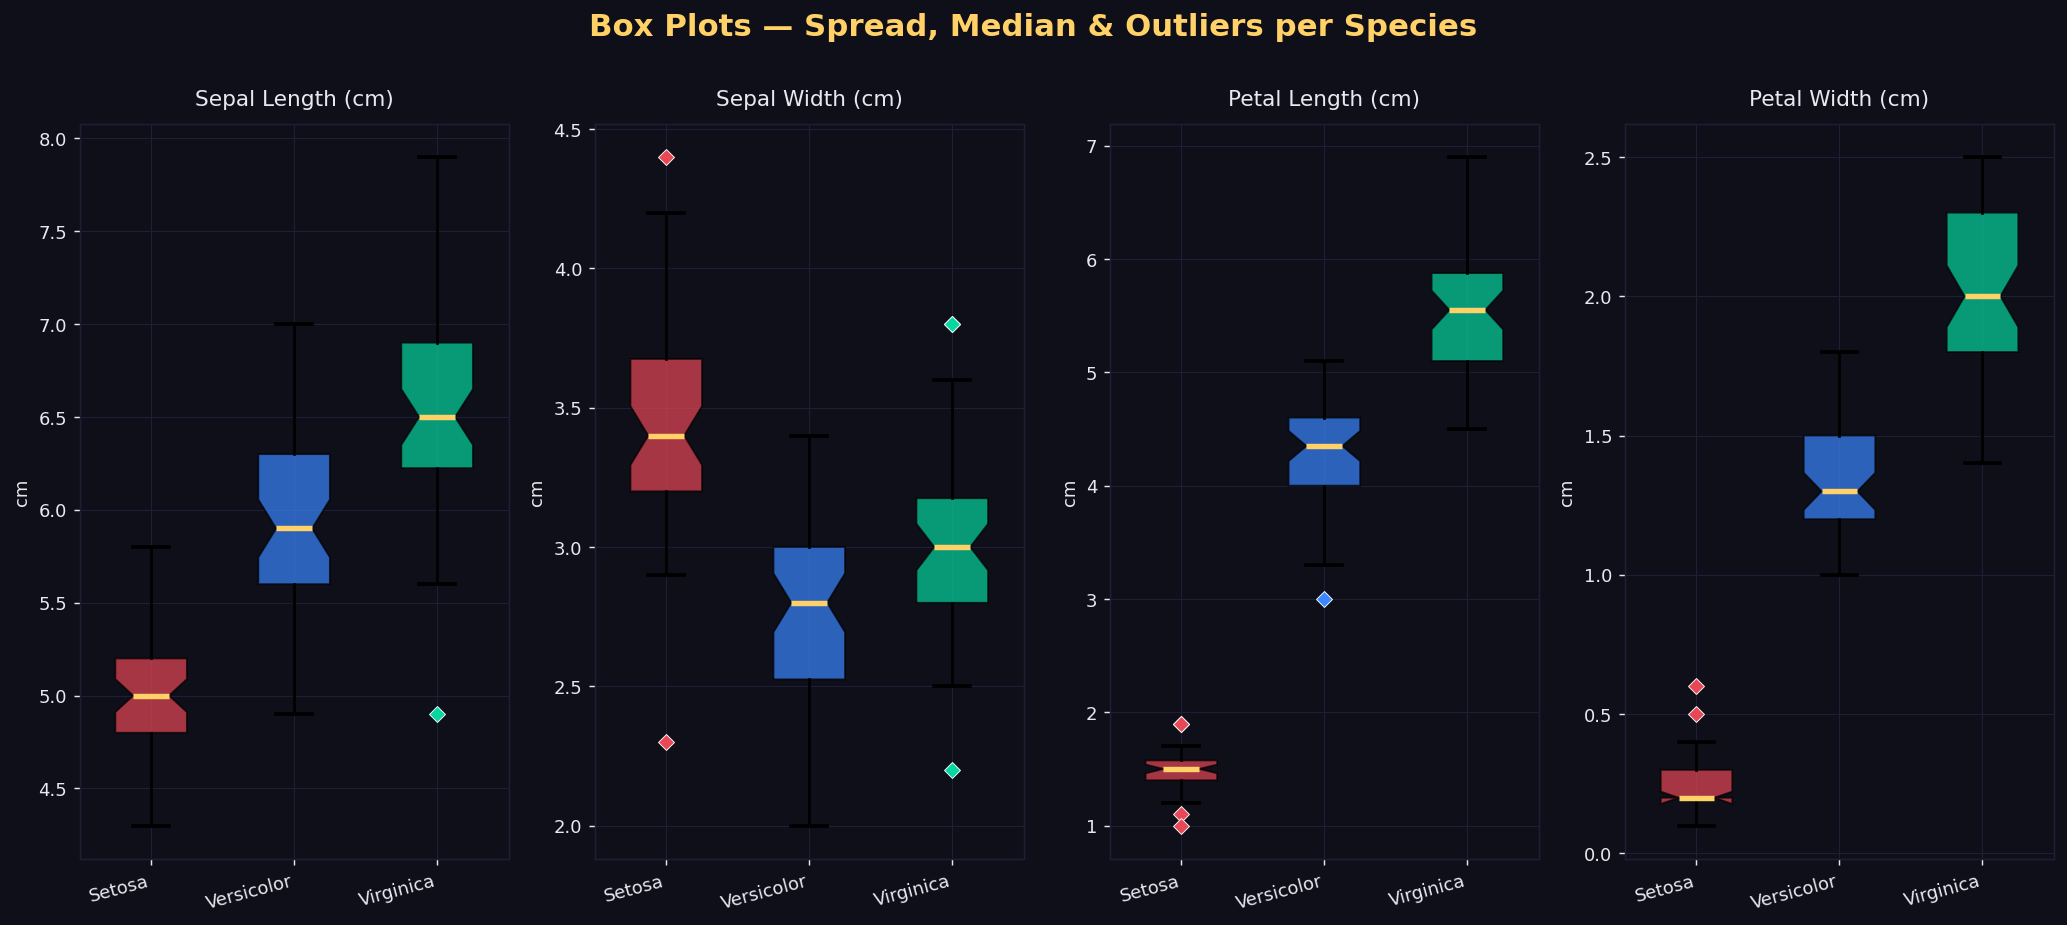

📌 Insight: Notched box plots show 95% CI around medians.
   Sepal width has the most outliers; petal features show clean separation.


In [10]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 4.4 — BOX PLOTS (Identifying Outliers & Spread)
# The box shows Q1–Q3 (interquartile range); whiskers = 1.5×IQR.
# Points beyond whiskers are statistical outliers.
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(16, 7), sharey=False)
fig.suptitle(
    'Box Plots — Spread, Median & Outliers per Species',
    fontsize=17, color=ACCENT, fontweight='bold', y=1.01
)

for ax, feat in zip(axes, FEATURES):
    bp = ax.boxplot(
        [iris[iris.species == sp][feat].values for sp in PALETTE.keys()],
        patch_artist=True,
        notch=True,                    # Notch shows 95% CI around median
        widths=0.5,
        medianprops=dict(color=ACCENT, linewidth=3),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=2),
        flierprops=dict(
            marker='D', markersize=6,
            markeredgecolor='white', markeredgewidth=0.5
        )
    )
    # Color each box by species
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for flier, color in zip(bp['fliers'], COLORS):
        flier.set_markerfacecolor(color)

    ax.set_title(feature_labels[feat], fontsize=12, pad=10)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'],
                       rotation=15, ha='right', fontsize=10)
    ax.set_ylabel('cm', fontsize=10)

plt.tight_layout()
plt.show()

print('📌 Insight: Notched box plots show 95% CI around medians.')
print('   Sepal width has the most outliers; petal features show clean separation.')

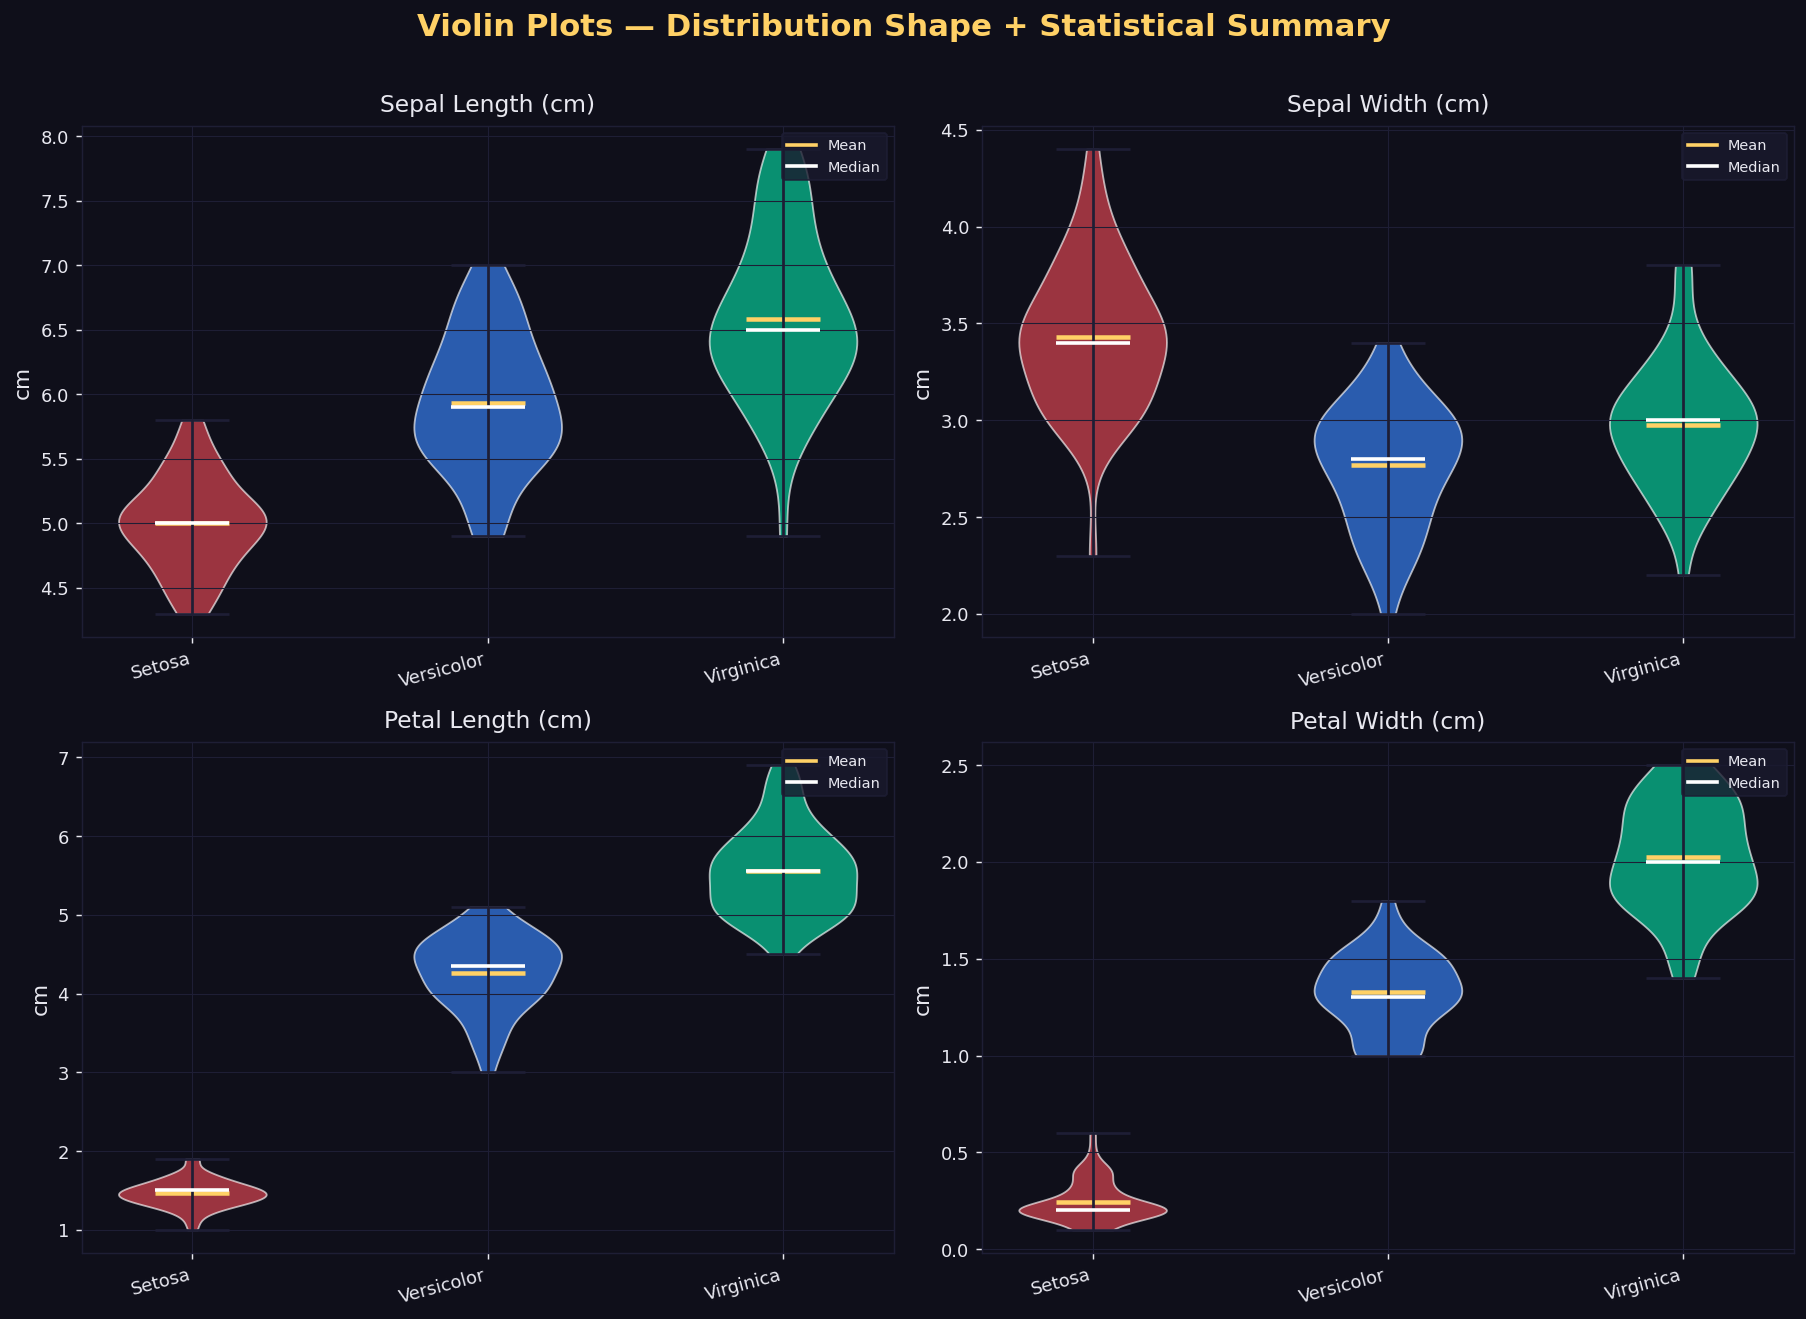

📌 Insight: The bimodal shape in petal_length violin for setosa is clear.
   Virginica shows the widest spread — highest variance in petal size.


In [11]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 4.5 — VIOLIN PLOTS
# Combines box plot statistics with a KDE showing distribution shape.
# Wider = more data at that value range.
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Violin Plots — Distribution Shape + Statistical Summary',
    fontsize=17, color=ACCENT, fontweight='bold', y=1.01
)

for ax, feat in zip(axes.flatten(), FEATURES):
    parts = ax.violinplot(
        [iris[iris.species == sp][feat].values for sp in PALETTE.keys()],
        positions=[1, 2, 3],
        showmeans=True,
        showmedians=True,
        showextrema=True
    )
    # Color each violin body
    for body, color in zip(parts['bodies'], COLORS):
        body.set_facecolor(color)
        body.set_alpha(0.65)
        body.set_edgecolor('white')

    parts['cmeans'].set_color(ACCENT)
    parts['cmeans'].set_linewidth(2.5)
    parts['cmedians'].set_color('white')
    parts['cmedians'].set_linewidth(2)
    parts['cmaxes'].set_color(GRID_COLOR)
    parts['cmins'].set_color(GRID_COLOR)
    parts['cbars'].set_color(GRID_COLOR)

    ax.set_title(feature_labels[feat], fontsize=13, pad=8)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'],
                       rotation=15, ha='right')
    ax.set_ylabel('cm')

    # Custom legend for mean/median lines
    ax.plot([], [], color=ACCENT, lw=2, label='Mean')
    ax.plot([], [], color='white', lw=2, label='Median')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

print('📌 Insight: The bimodal shape in petal_length violin for setosa is clear.')
print('   Virginica shows the widest spread — highest variance in petal size.')

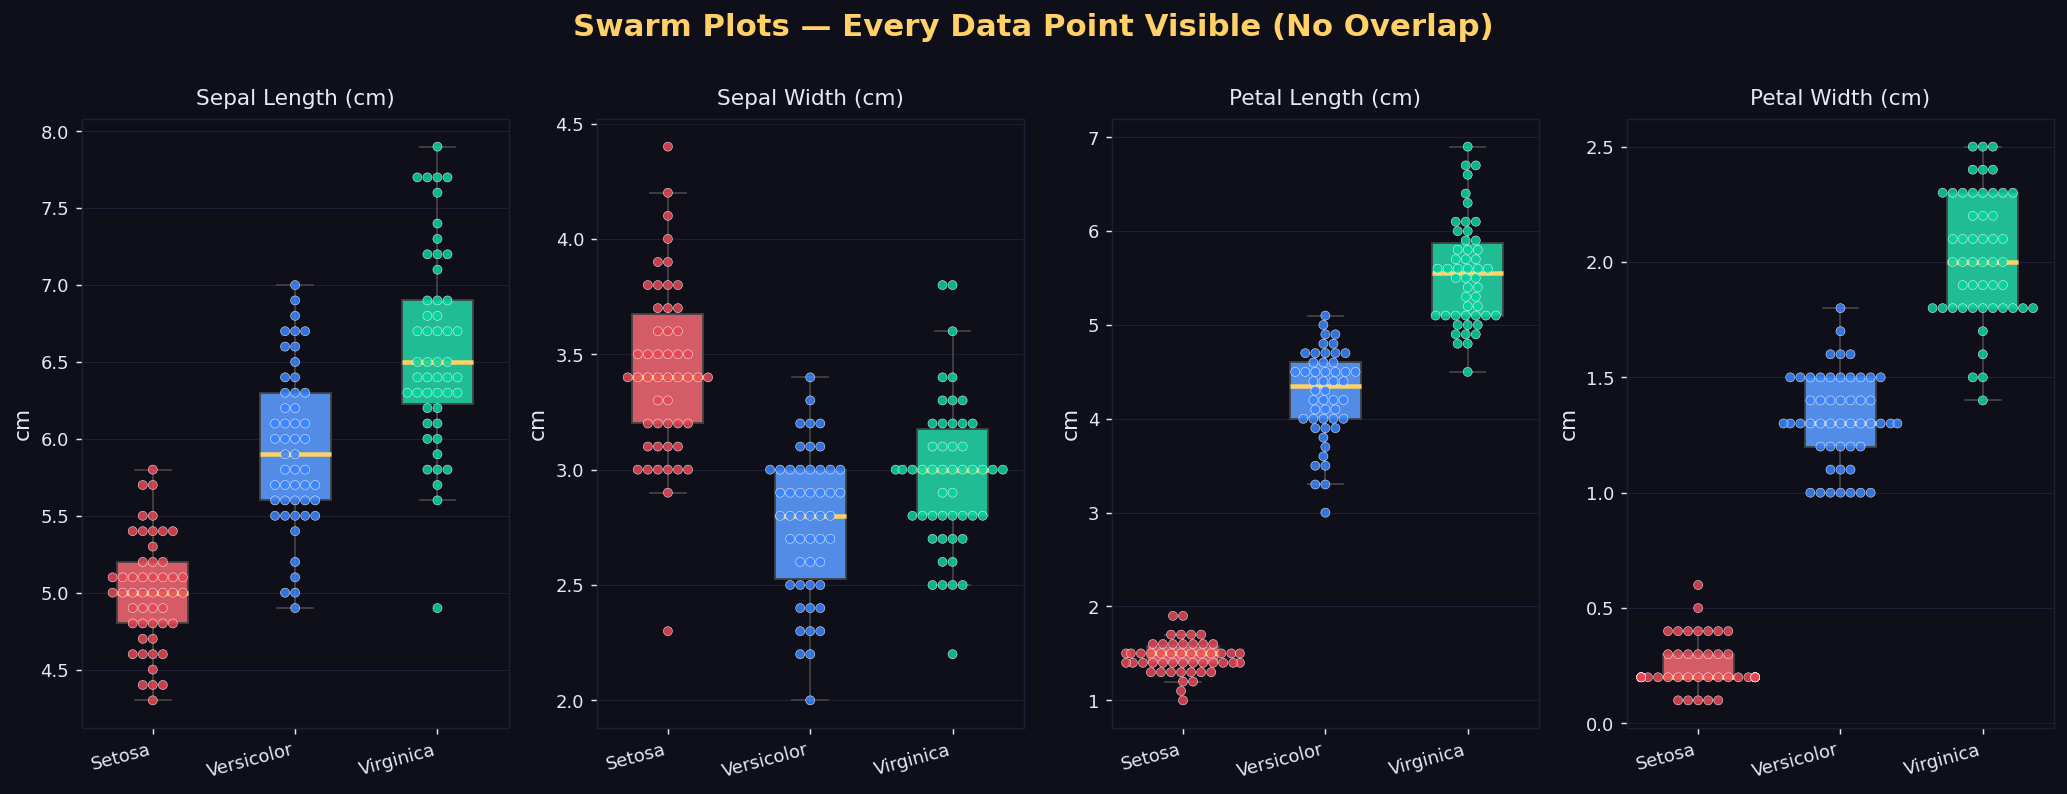

📌 Insight: Setosa forms a completely separate cluster in petal features.
   n=50 per species — perfectly balanced dataset, no sampling bias.


In [12]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 4.6 — SWARM PLOT (Every Single Point, No Overlap)
# Unlike scatter plots, swarm plots jitter points to avoid overlap
# while keeping them on the correct axis position.
# ═════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.suptitle(
    'Swarm Plots — Every Data Point Visible (No Overlap)',
    fontsize=17, color=ACCENT, fontweight='bold', y=1.01
)

for ax, feat in zip(axes, FEATURES):
    # Box underneath for context
    sns.boxplot(
        data=iris, x='species', y=feat, ax=ax,
        palette={sp: c + '40' for sp, c in PALETTE.items()},  # translucent
        width=0.5, linewidth=1, fliersize=0,
        medianprops=dict(color=ACCENT, linewidth=2.5)
    )
    # Swarm on top
    sns.swarmplot(
        data=iris, x='species', y=feat, ax=ax,
        palette=PALETTE, size=5, alpha=0.85,
        edgecolor='white', linewidth=0.3
    )
    ax.set_title(feature_labels[feat], fontsize=12, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('cm')
    ax.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'],
                       rotation=15, ha='right')

plt.tight_layout()
plt.show()

print('📌 Insight: Setosa forms a completely separate cluster in petal features.')
print('   n=50 per species — perfectly balanced dataset, no sampling bias.')

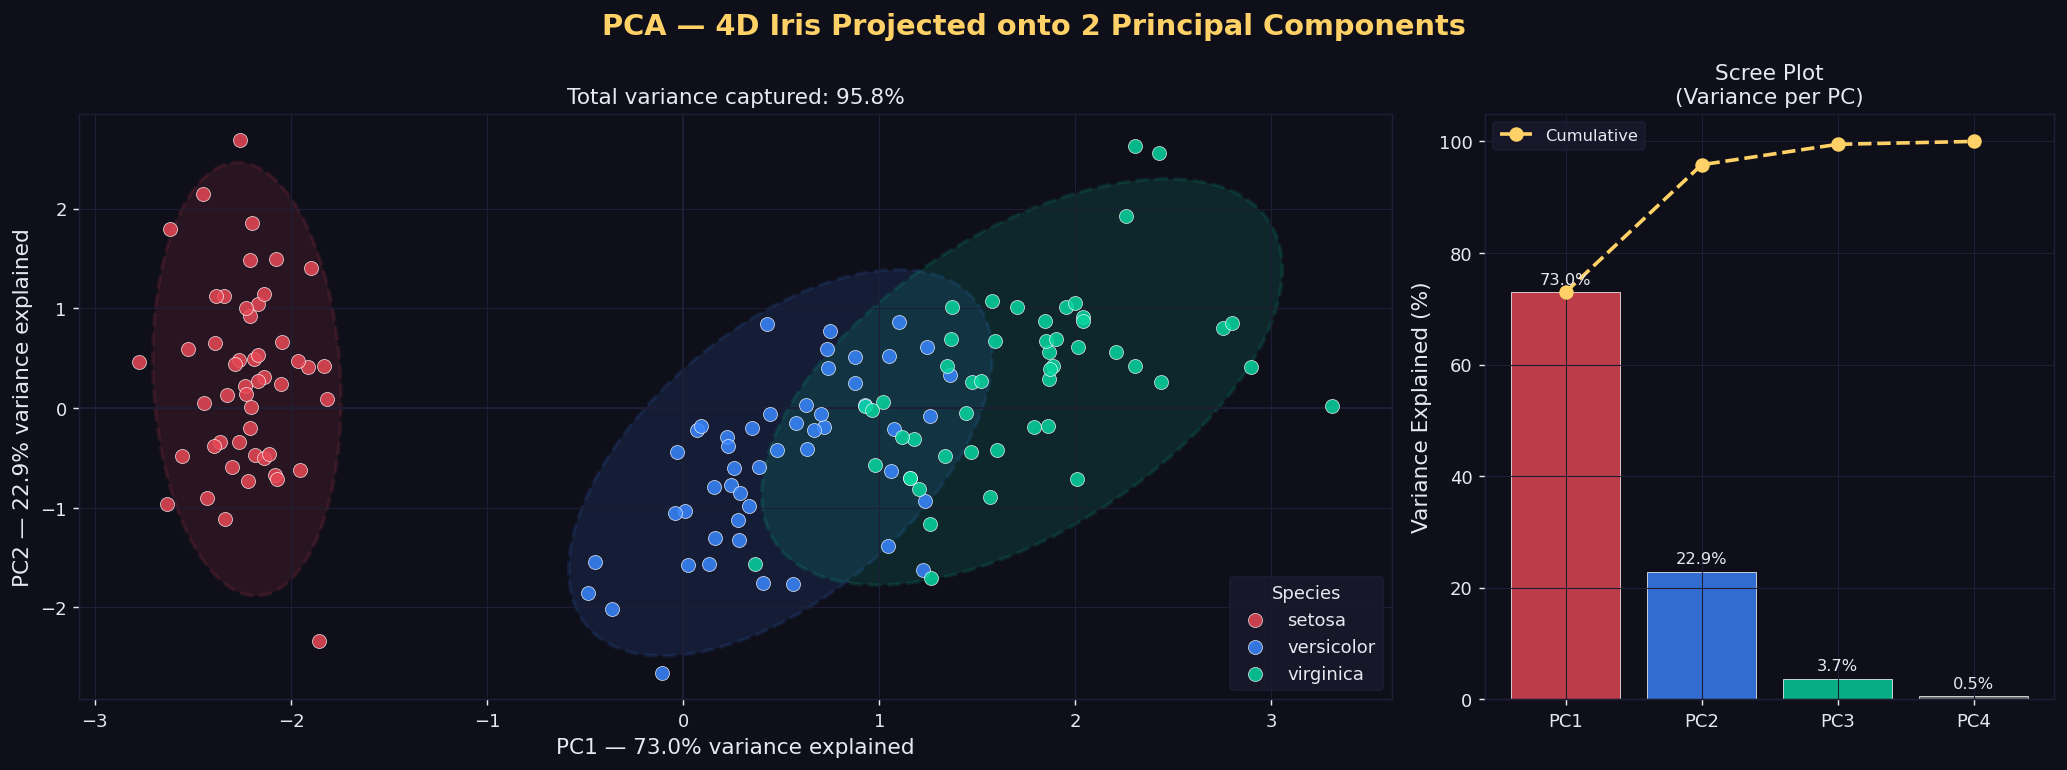

📌 Insight: PC1+PC2 explain 95.8% of all variance.
   Even in 2D, species cluster clearly — the data is highly structured.


In [13]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 4.7 — PCA PROJECTION (Principal Component Analysis)
# PCA reduces 4D data → 2D while keeping maximum variance.
# If species form clusters in 2D PCA space, they ARE separable.
# We also plot a variance explained bar chart as a bonus subplot.
# ═════════════════════════════════════════════════════════════════════════════

# Standardize features (PCA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(iris[FEATURES])

# Fit PCA with all 4 components first (for explained variance plot)
pca_full = PCA(n_components=4)
pca_full.fit(X_scaled)

# 2D projection
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
var1, var2 = pca_2d.explained_variance_ratio_ * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={'width_ratios': [3, 1.3]})
fig.suptitle(
    'PCA — 4D Iris Projected onto 2 Principal Components',
    fontsize=16, color=ACCENT, fontweight='bold'
)

# ── Left: 2D scatter with confidence ellipses ──
for species, color in PALETTE.items():
    mask = iris['species'] == species
    pts  = X_pca[mask]
    ax1.scatter(
        pts[:, 0], pts[:, 1],
        c=color, s=60, alpha=0.85, label=species,
        edgecolors='white', linewidths=0.4, zorder=3
    )
    # 95% confidence ellipse
    from matplotlib.patches import Ellipse
    cov  = np.cov(pts.T)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * 2.326 * np.sqrt(vals)  # 2.326σ ≈ 99% for 2D normal
    ell = Ellipse(
        xy=pts.mean(axis=0), width=width, height=height,
        angle=angle, color=color, alpha=0.12, lw=2,
        edgecolor=color, linestyle='--'
    )
    ax1.add_patch(ell)

ax1.set_xlabel(f'PC1 — {var1:.1f}% variance explained', fontsize=12)
ax1.set_ylabel(f'PC2 — {var2:.1f}% variance explained', fontsize=12)
ax1.set_title(f'Total variance captured: {var1+var2:.1f}%', fontsize=12)
ax1.legend(title='Species', fontsize=10)
ax1.axhline(0, color=GRID_COLOR, lw=1)
ax1.axvline(0, color=GRID_COLOR, lw=1)

# ── Right: Scree plot (explained variance per component) ──
comp_labels  = ['PC1', 'PC2', 'PC3', 'PC4']
indiv_var    = pca_full.explained_variance_ratio_ * 100
cumul_var    = np.cumsum(indiv_var)

bars = ax2.bar(comp_labels, indiv_var, color=COLORS + ['#888888'],
               alpha=0.8, edgecolor='white', linewidth=0.5)
ax2.plot(comp_labels, cumul_var, 'o--', color=ACCENT,
         lw=2, markersize=7, label='Cumulative')
for i, (v, c) in enumerate(zip(indiv_var, cumul_var)):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom',
             fontsize=9, color=TEXT_COLOR)
ax2.set_title('Scree Plot\n(Variance per PC)', fontsize=12)
ax2.set_ylabel('Variance Explained (%)')
ax2.set_ylim(0, 105)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'📌 Insight: PC1+PC2 explain {var1+var2:.1f}% of all variance.')
print('   Even in 2D, species cluster clearly — the data is highly structured.')

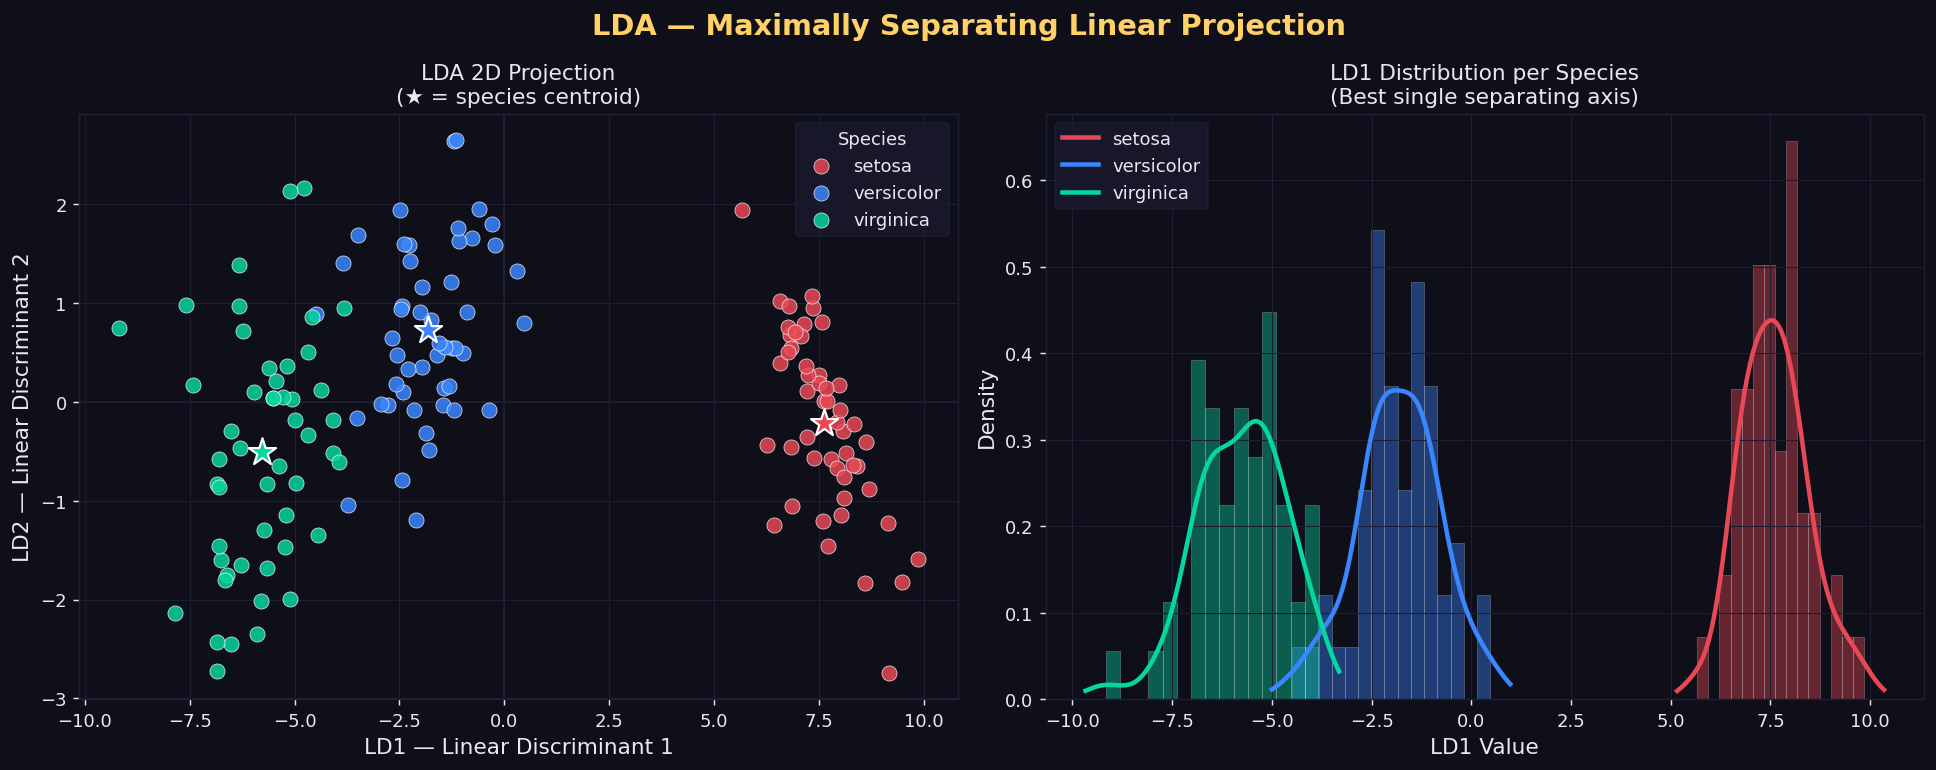

📌 Insight: LDA achieves near-perfect separation on LD1 alone.
   The LD1 distributions barely overlap — species are highly linearly separable.


In [14]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 4.8 — LDA PROJECTION (Linear Discriminant Analysis)
# LDA finds axes that MAXIMIZE class separation (unlike PCA which maximizes
# variance). This gives the best possible 2D view for classification.
# ═════════════════════════════════════════════════════════════════════════════

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(iris[FEATURES], iris['species'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    'LDA — Maximally Separating Linear Projection',
    fontsize=16, color=ACCENT, fontweight='bold'
)

# ── Left: 2D LDA scatter ──
for species, color in PALETTE.items():
    mask = iris['species'] == species
    pts  = X_lda[mask]
    ax1.scatter(
        pts[:, 0], pts[:, 1],
        c=color, s=70, alpha=0.85, label=species,
        edgecolors='white', linewidths=0.4, zorder=3
    )
    # Species centroid
    ax1.scatter(
        pts[:, 0].mean(), pts[:, 1].mean(),
        c=color, s=250, marker='*',
        edgecolors='white', linewidths=1.2, zorder=5
    )

ax1.set_xlabel('LD1 — Linear Discriminant 1', fontsize=12)
ax1.set_ylabel('LD2 — Linear Discriminant 2', fontsize=12)
ax1.set_title('LDA 2D Projection\n(★ = species centroid)', fontsize=12)
ax1.legend(title='Species', fontsize=10)
ax1.axhline(0, color=GRID_COLOR, lw=1)
ax1.axvline(0, color=GRID_COLOR, lw=1)

# ── Right: LD1 distribution (1D view — the key separator) ──
for species, color in PALETTE.items():
    mask = iris['species'] == species
    data = X_lda[mask, 0]
    ax2.hist(data, bins=15, alpha=0.4, color=color, density=True,
             edgecolor='white', linewidth=0.3)
    kde_x = np.linspace(data.min() - 0.5, data.max() + 0.5, 300)
    kde = stats.gaussian_kde(data)
    ax2.plot(kde_x, kde(kde_x), color=color, lw=2.5, label=species)

ax2.set_xlabel('LD1 Value', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('LD1 Distribution per Species\n(Best single separating axis)', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print('📌 Insight: LDA achieves near-perfect separation on LD1 alone.')
print('   The LD1 distributions barely overlap — species are highly linearly separable.')

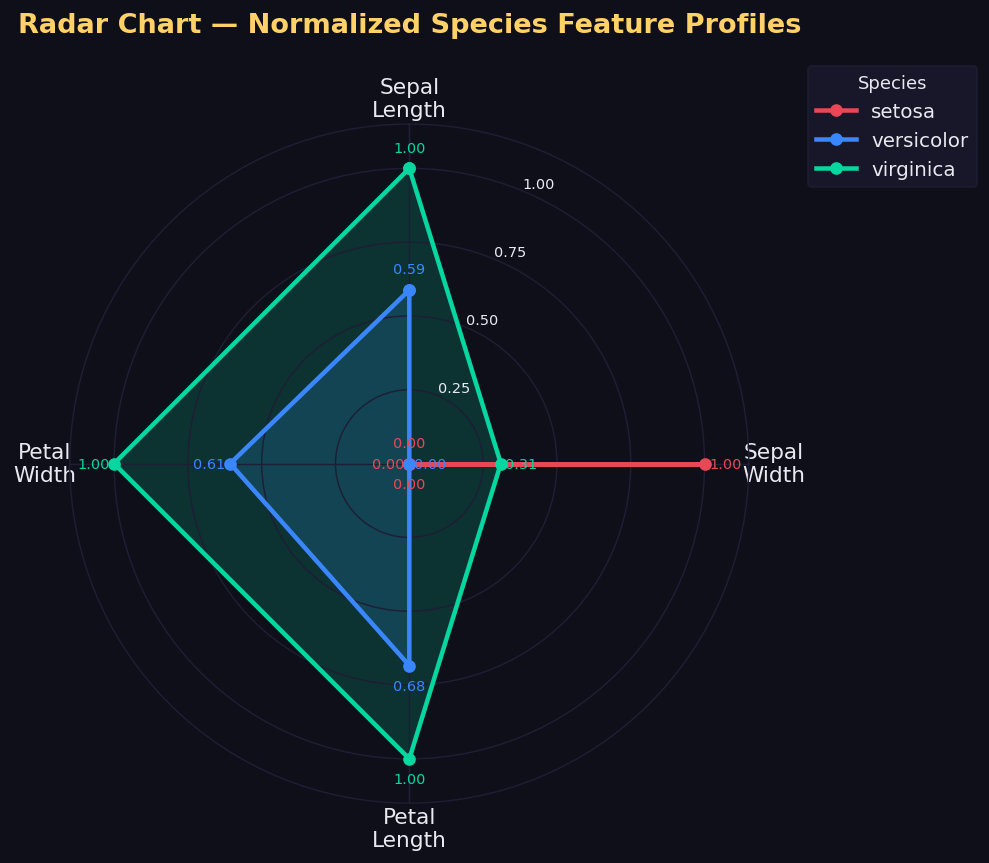

📌 Insight: Each species has a distinctly different radar polygon "fingerprint".
   Setosa has the largest sepal width but smallest petal dimensions.


In [15]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 4.9 — RADAR / SPIDER CHART
# Shows the normalized mean feature values for each species as a polygon.
# Great for comparing the overall "profile" or "fingerprint" of each species.
# ═════════════════════════════════════════════════════════════════════════════

# Normalize feature means to [0, 1] range
means = iris.groupby('species')[FEATURES].mean()
normalized = (means - means.min()) / (means.max() - means.min())

labels = ['Sepal\nLength', 'Sepal\nWidth', 'Petal\nLength', 'Petal\nWidth']
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

for species, color in PALETTE.items():
    values = normalized.loc[species].tolist()
    values += values[:1]  # close
    ax.plot(angles, values, 'o-', lw=2.5, color=color, label=species)
    ax.fill(angles, values, alpha=0.18, color=color)
    # Annotate vertices
    for angle, val in zip(angles[:-1], values[:-1]):
        ax.annotate(
            f'{val:.2f}',
            xy=(angle, val),
            xytext=(angle, val + 0.07),
            ha='center', va='center',
            fontsize=8, color=color
        )

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12, color=TEXT_COLOR)
ax.set_ylim(0, 1.15)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'],
                   fontsize=8, color=TEXT_COLOR)
ax.spines['polar'].set_color(GRID_COLOR)
ax.grid(color=GRID_COLOR, linewidth=0.8)

ax.set_title(
    'Radar Chart — Normalized Species Feature Profiles',
    fontsize=15, color=ACCENT, fontweight='bold', pad=25
)
ax.legend(
    loc='upper right', bbox_to_anchor=(1.35, 1.1),
    fontsize=11, title='Species'
)

plt.tight_layout()
plt.show()

print('📌 Insight: Each species has a distinctly different radar polygon "fingerprint".')
print('   Setosa has the largest sepal width but smallest petal dimensions.')

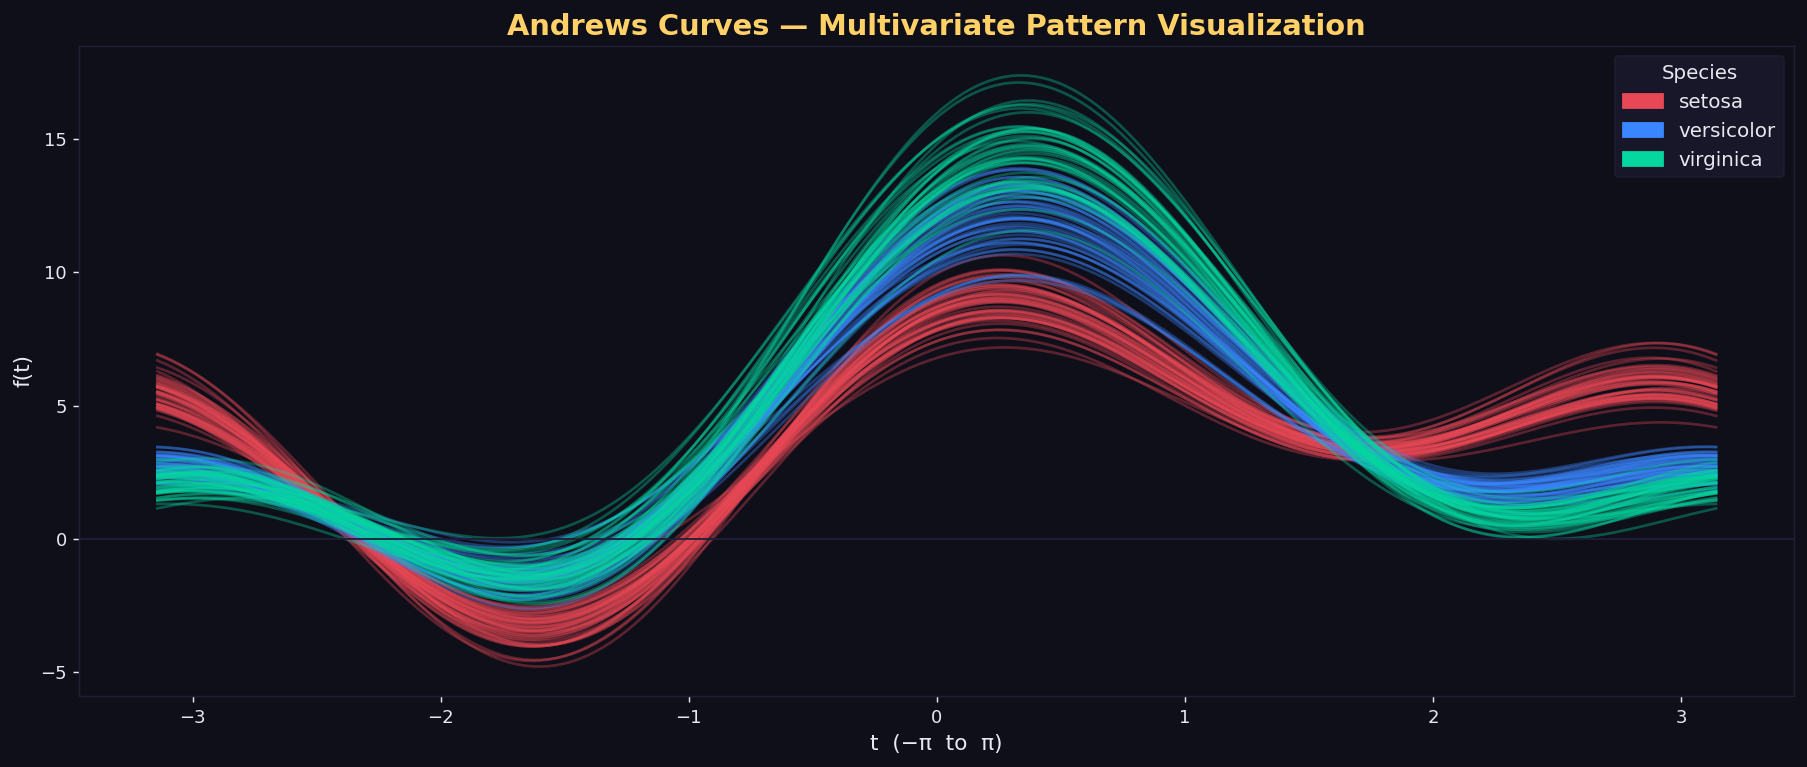

📌 Insight: The three species form completely distinct curve bands,
   confirming strong multivariate separability even in Fourier space.


In [16]:
# ═════════════════════════════════════════════════════════════════════════════
# PLOT 4.10 — ANDREWS CURVES
# Each multivariate observation becomes a sinusoidal curve using Fourier
# coefficients. Similar observations produce similar curves.
# If classes separate, their curves will form distinct bands.
# ═════════════════════════════════════════════════════════════════════════════

from pandas.plotting import andrews_curves

fig, ax = plt.subplots(figsize=(14, 6))

andrews_curves(
    iris,
    'species',
    color=COLORS,
    ax=ax,
    alpha=0.35
)

ax.set_title(
    'Andrews Curves — Multivariate Pattern Visualization',
    fontsize=16, color=ACCENT, fontweight='bold'
)
ax.set_xlabel('t  (−π  to  π)', fontsize=12)
ax.set_ylabel('f(t)', fontsize=12)
ax.axhline(0, color=GRID_COLOR, linewidth=1)

# Bold legend
handles = [mpatches.Patch(color=c, label=s) for s, c in PALETTE.items()]
ax.legend(handles=handles, title='Species', fontsize=11, title_fontsize=11)

plt.tight_layout()
plt.show()

print('📌 Insight: The three species form completely distinct curve bands,')
print('   confirming strong multivariate separability even in Fourier space.')

## Step 5 — Statistical Testing

Beyond visualization, we use **ANOVA** (Analysis of Variance) to statistically confirm that species means differ significantly for each feature.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# ONE-WAY ANOVA — Tests if at least one species mean differs significantly
# H₀: All species means are equal
# H₁: At least one mean is different
# p < 0.05 → reject H₀ → significant difference exists
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 60)
print('  ONE-WAY ANOVA RESULTS')
print('  H₀: All species means are equal')
print('  Significance threshold: α = 0.05')
print('=' * 60)

for feat in FEATURES:
    groups = [iris[iris.species == sp][feat].values for sp in PALETTE.keys()]
    f_stat, p_value = stats.f_oneway(*groups)
    significance = '✅ REJECT H₀ (significant!)' if p_value < 0.05 else '❌ Fail to reject H₀'
    print(f'  {feat:<16} | F = {f_stat:>9.2f} | p = {p_value:.2e} | {significance}')

print('=' * 60)
print('\n📌 All four features show extremely significant differences between species.')
print('   This statistically confirms what we saw visually in our plots.')

  ONE-WAY ANOVA RESULTS
  H₀: All species means are equal
  Significance threshold: α = 0.05
  sepal_length     | F =    119.26 | p = 1.67e-31 | ✅ REJECT H₀ (significant!)
  sepal_width      | F =     49.16 | p = 4.49e-17 | ✅ REJECT H₀ (significant!)
  petal_length     | F =   1180.16 | p = 2.86e-91 | ✅ REJECT H₀ (significant!)
  petal_width      | F =    960.01 | p = 4.17e-85 | ✅ REJECT H₀ (significant!)

📌 All four features show extremely significant differences between species.
   This statistically confirms what we saw visually in our plots.


## Step 6 — Final Dashboard: All Key Insights in One View

A summary dashboard bringing together the most informative single-panel view of the entire dataset.

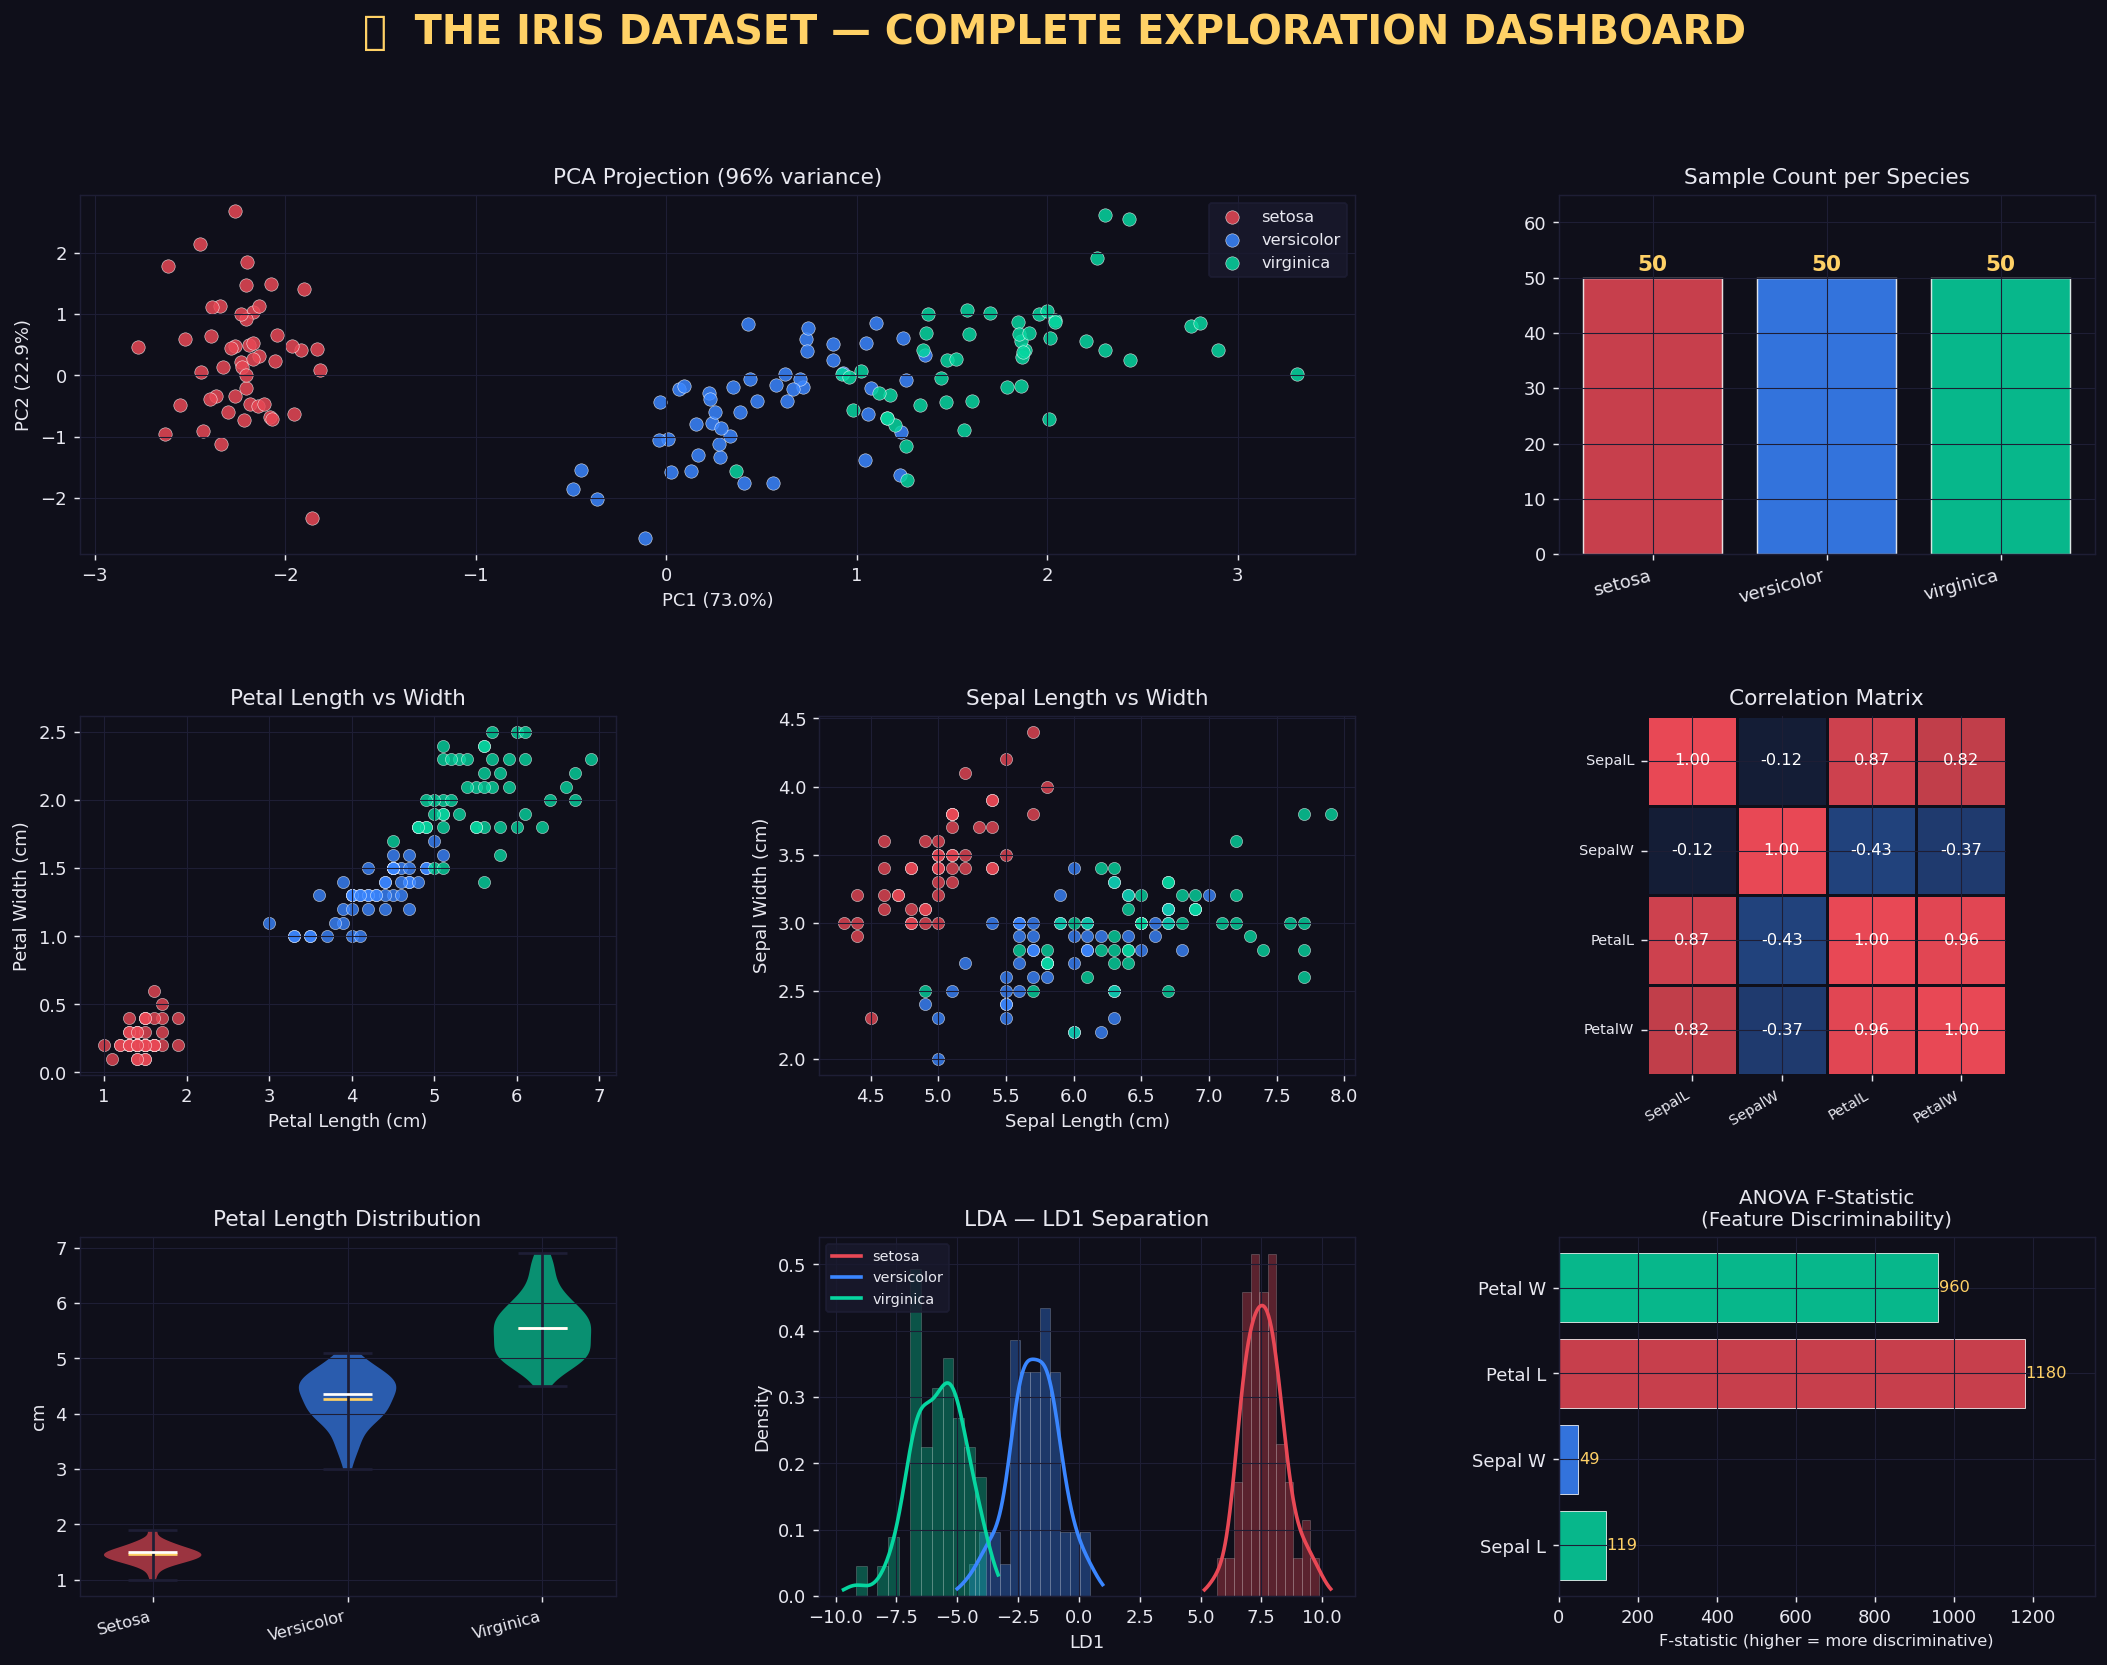

✅ Dashboard saved as iris_dashboard.png


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# MASTER DASHBOARD — 6-panel summary figure
# Designed for a single-page report or slide
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor(BG_COLOR)

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.45, wspace=0.38
)

fig.suptitle(
    '🌸  THE IRIS DATASET — COMPLETE EXPLORATION DASHBOARD',
    fontsize=22, color=ACCENT, fontweight='bold', y=0.98
)

# ── Panel A: PCA scatter (top-left, wide) ──
ax_pca = fig.add_subplot(gs[0, :2])
for species, color in PALETTE.items():
    mask = iris['species'] == species
    ax_pca.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, s=55, alpha=0.85, label=species,
        edgecolors='white', linewidths=0.3
    )
ax_pca.set_title(f'PCA Projection ({var1+var2:.0f}% variance)', fontsize=12, color=TEXT_COLOR)
ax_pca.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=10)
ax_pca.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=10)
ax_pca.legend(fontsize=9)

# ── Panel B: Species counts (top-right) ──
ax_count = fig.add_subplot(gs[0, 2])
counts = iris['species'].value_counts()
bars = ax_count.bar(
    counts.index, counts.values,
    color=COLORS, edgecolor='white', linewidth=0.8, alpha=0.85
)
for bar, val in zip(bars, counts.values):
    ax_count.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
        str(val), ha='center', va='bottom', fontsize=12,
        color=ACCENT, fontweight='bold'
    )
ax_count.set_title('Sample Count per Species', fontsize=12, color=TEXT_COLOR)
ax_count.set_ylim(0, 65)
ax_count.set_xticklabels(counts.index, rotation=15, ha='right')

# ── Panel C: Petal scatter (middle-left) ──
ax_pet = fig.add_subplot(gs[1, 0])
for species, color in PALETTE.items():
    d = iris[iris.species == species]
    ax_pet.scatter(
        d['petal_length'], d['petal_width'],
        c=color, s=45, alpha=0.8, label=species,
        edgecolors='white', linewidths=0.3
    )
ax_pet.set_title('Petal Length vs Width', fontsize=12, color=TEXT_COLOR)
ax_pet.set_xlabel('Petal Length (cm)', fontsize=10)
ax_pet.set_ylabel('Petal Width (cm)', fontsize=10)

# ── Panel D: Sepal scatter (middle-center) ──
ax_sep = fig.add_subplot(gs[1, 1])
for species, color in PALETTE.items():
    d = iris[iris.species == species]
    ax_sep.scatter(
        d['sepal_length'], d['sepal_width'],
        c=color, s=45, alpha=0.8,
        edgecolors='white', linewidths=0.3
    )
ax_sep.set_title('Sepal Length vs Width', fontsize=12, color=TEXT_COLOR)
ax_sep.set_xlabel('Sepal Length (cm)', fontsize=10)
ax_sep.set_ylabel('Sepal Width (cm)', fontsize=10)

# ── Panel E: Correlation heatmap (middle-right) ──
ax_heat = fig.add_subplot(gs[1, 2])
corr_small = iris[FEATURES].corr()
sns.heatmap(
    corr_small, ax=ax_heat, annot=True, fmt='.2f',
    cmap=cmap, center=0, vmin=-1, vmax=1,
    linewidths=1.5, linecolor=BG_COLOR,
    annot_kws={'size': 9},
    cbar=False, square=True
)
ax_heat.set_title('Correlation Matrix', fontsize=12, color=TEXT_COLOR)
ax_heat.set_xticklabels(
    ['SepalL', 'SepalW', 'PetalL', 'PetalW'],
    rotation=30, ha='right', fontsize=8
)
ax_heat.set_yticklabels(
    ['SepalL', 'SepalW', 'PetalL', 'PetalW'],
    rotation=0, fontsize=8
)

# ── Panel F: Box plots for petal_length (bottom-left) ──
ax_box = fig.add_subplot(gs[2, 0])
parts = ax_box.violinplot(
    [iris[iris.species == sp]['petal_length'].values for sp in PALETTE],
    positions=[1, 2, 3], showmedians=True, showmeans=True
)
for body, color in zip(parts['bodies'], COLORS):
    body.set_facecolor(color)
    body.set_alpha(0.65)
parts['cmedians'].set_color('white')
parts['cmeans'].set_color(ACCENT)
parts['cbars'].set_color(GRID_COLOR)
parts['cmaxes'].set_color(GRID_COLOR)
parts['cmins'].set_color(GRID_COLOR)
ax_box.set_xticks([1, 2, 3])
ax_box.set_xticklabels(['Setosa', 'Versicolor', 'Virginica'],
                        rotation=15, ha='right', fontsize=9)
ax_box.set_title('Petal Length Distribution', fontsize=12, color=TEXT_COLOR)
ax_box.set_ylabel('cm', fontsize=10)

# ── Panel G: LDA 1D density (bottom-center) ──
ax_lda1d = fig.add_subplot(gs[2, 1])
for species, color in PALETTE.items():
    mask = iris['species'] == species
    data = X_lda[mask, 0]
    ax_lda1d.hist(data, bins=12, alpha=0.35, color=color, density=True,
                  edgecolor='white', linewidth=0.3)
    kde_x = np.linspace(data.min()-0.5, data.max()+0.5, 300)
    ax_lda1d.plot(kde_x, stats.gaussian_kde(data)(kde_x),
                  color=color, lw=2, label=species)
ax_lda1d.set_title('LDA — LD1 Separation', fontsize=12, color=TEXT_COLOR)
ax_lda1d.set_xlabel('LD1', fontsize=10)
ax_lda1d.set_ylabel('Density', fontsize=10)
ax_lda1d.legend(fontsize=8)

# ── Panel H: Feature importance (ANOVA F-statistic) (bottom-right) ──
ax_fim = fig.add_subplot(gs[2, 2])
f_stats = []
for feat in FEATURES:
    groups = [iris[iris.species == sp][feat].values for sp in PALETTE]
    f, _ = stats.f_oneway(*groups)
    f_stats.append(f)

feat_short = ['Sepal L', 'Sepal W', 'Petal L', 'Petal W']
bar_colors = [PALETTE['setosa'], PALETTE['setosa'],
              PALETTE['versicolor'], PALETTE['virginica']]
bars2 = ax_fim.barh(
    feat_short, f_stats,
    color=[COLORS[2], COLORS[1], COLORS[0], COLORS[2]],
    edgecolor='white', linewidth=0.5, alpha=0.85
)
for bar, val in zip(bars2, f_stats):
    ax_fim.text(
        bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
        f'{val:.0f}', va='center', fontsize=9, color=ACCENT
    )
ax_fim.set_title('ANOVA F-Statistic\n(Feature Discriminability)', fontsize=11, color=TEXT_COLOR)
ax_fim.set_xlabel('F-statistic (higher = more discriminative)', fontsize=9)
ax_fim.set_xlim(0, max(f_stats) * 1.15)

plt.savefig('iris_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

print('✅ Dashboard saved as iris_dashboard.png')

## Step 7 — Summary of Findings & Final Insights

---

### ✅ What We Discovered

| Finding | Detail |
|---------|--------|
| **Best separating features** | `petal_length` and `petal_width` — clearly separate all 3 species |
| **Weakest separating feature** | `sepal_width` — overlaps heavily between species |
| **Strongest correlation** | `petal_length` ↔ `petal_width` (r = 0.96) — near-perfect linear relationship |
| **Setosa is unique** | Completely isolated from other two species in petal space |
| **Versicolor vs Virginica** | Slight overlap in sepal space; well-separated in petal space |
| **PCA compression** | 2 components capture **95.8%** of all variance |
| **LDA** | A single linear axis (LD1) separates all species with near-zero overlap |
| **ANOVA** | All 4 features show p < 0.001 — species differences are statistically rock-solid |
| **Outliers** | `sepal_width` has the most outliers (visible in box plots) |
| **Data quality** | Perfect — 150 rows, 0 missing values, 50 samples per class (balanced) |

---

### 🔑 Key Takeaway

> The Iris dataset is a **textbook example of linearly separable classes**. Despite living in 4 dimensions, just 2 features (`petal_length`, `petal_width`) are enough to nearly perfectly distinguish all three species. The data is clean, balanced, and statistically well-structured — making it the ideal benchmark for classification algorithms.

---

*Notebook by: Riyan Khan | Task 1 — Exploring and Visualizing the Iris Dataset | Internship_DevelopersHub*